In [ ]:
import pandas as pd

In [ ]:
campeoes_df = pd.read_csv('datasets/campeões.csv')
players_df = pd.read_csv('datasets/players.csv.csv')
games_df = pd.read_csv('datasets/games.csv')

print("Primeiros registros do DataFrame campeões:")
print(campeoes_df.head())

print("\nPrimeiros registros do DataFrame players:")
print(players_df.head())

print("\nPrimeiros registros do DataFrame games:")
print(games_df.head())

Primeiros registros do DataFrame campeões:
   ID          NAME      Type
0  62        Wukong   Fighter
1  24           Jax   Fighter
2   9  Fiddlesticks      Mage
3  35         Shaco  Assassin
4  19       Warwick   Fighter

Primeiros registros do DataFrame players:
   ID_PLAYER  CAMPEÃO  WIN
0          1       62    1
1          1       24    0
2          1      420    1
3          1      122    1
4          1       24    0

Primeiros registros do DataFrame games:
       gameId   creationTime  gameDuration  seasonId  winner  firstBlood  \
0  3326086514  1504279457970          1949         9       1           2   
1  3229566029  1497848803862          1851         9       1           1   
2  3327363504  1504360103310          1493         9       1           2   
3  3326856598  1504348503996          1758         9       1           1   
4  3330080762  1504554410899          2094         9       1           2   

   firstTower  firstInhibitor  firstBaron  firstDragon  ...  t2_towerKills

In [ ]:
def recomendar_por_conteudo(player_id, players_df, campeoes_df, top_n=5):

    player_games = players_df[players_df['ID_PLAYER'] == player_id]
    most_played_champions = player_games['CAMPEÃO'].value_counts().index[:top_n]
    played_champions_types = campeoes_df[campeoes_df['ID'].isin(most_played_champions)]['Type']
    common_type = played_champions_types.value_counts().index[0]
    recommendations = campeoes_df[campeoes_df['Type'] == common_type]
    recommendations = recommendations[~recommendations['ID'].isin(most_played_champions)]

    return recommendations.head(top_n)

In [ ]:
def recomendar_para_usuario_novo(campeoes_df, top_n=5):

    categorias = campeoes_df['Type'].unique()
    recomendacoes = pd.DataFrame()

    for categoria in categorias:
        campeoes_categoria = campeoes_df[campeoes_df['Type'] == categoria]
        campeoes_populares = campeoes_categoria.head(top_n)
        recomendacoes = pd.concat([recomendacoes, campeoes_populares])

    return recomendacoes

In [ ]:
def recomendar_novo_item_para_usuario_antigo(player_id, players_df, campeoes_df, top_n=1):

    player_games = players_df[players_df['ID_PLAYER'] == player_id]
    most_played_champions = player_games['CAMPEÃO'].value_counts().index
    all_champions = set(campeoes_df['ID'])
    unplayed_champions = all_champions - set(most_played_champions)
    recommendations = campeoes_df[campeoes_df['ID'].isin(unplayed_champions)].head(top_n)

    return recommendations

     ID          NAME      Type
0    62        Wukong   Fighter
2     9  Fiddlesticks      Mage
3    35         Shaco  Assassin
5   498         Xayah  Marksman
10   33        Rammus      Tank


   ID          NAME  Type
2   9  Fiddlesticks  Mage


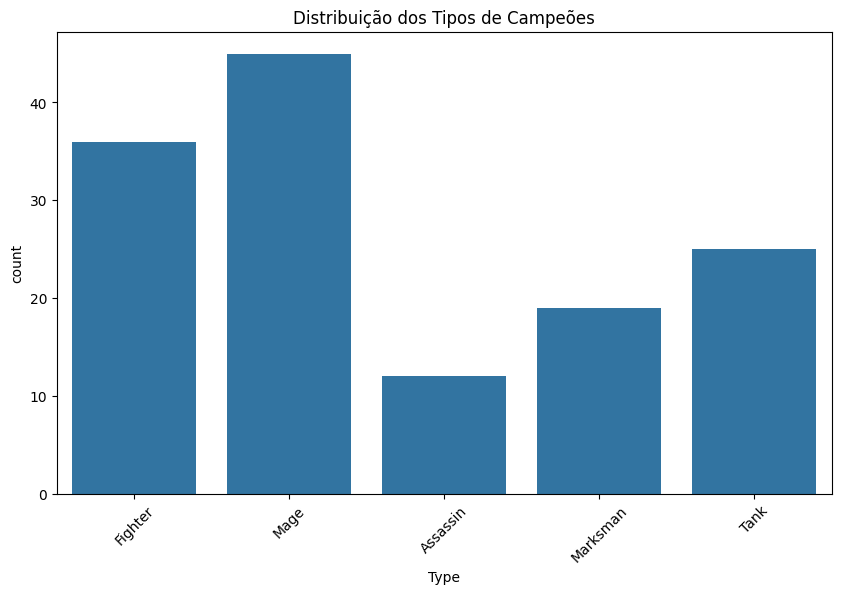

In [ ]:
# Visualização da distribuição dos tipos de campeões
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=campeoes_df, x='Type')
plt.title('Distribuição dos Tipos de Campeões')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def user_interface():
    output = widgets.Output()

    def on_button_clicked(b):
        with output:
            clear_output()
            player_id = player_id_widget.value
            recommendation_type = recommendation_type_widget.value

            if player_id not in players_df['ID_PLAYER'].unique():
                print("Jogador novo detectado.")
                recommendations = recomendar_campeoes_usuario_novo(campeoes_df)
            else:
                if recommendation_type == 'Algo que combine com você':
                    recommendations = recomendar_campeoes_usuario_antigo(player_id, players_df, campeoes_df)
                elif recommendation_type == 'Algo novo':
                    recommendations = recomendar_novo_campeao_usuario_antigo(player_id, players_df, campeoes_df)

            print(recommendations)

    player_id_widget = widgets.IntText(
        value=1,
        description='ID do jogador:',
        disabled=False
    )

    recommendation_type_widget = widgets.RadioButtons(
        options=['Algo que combine com você', 'Algo novo'],
        description='Tipo de recomendação:',
        disabled=False
    )

    button = widgets.Button(description="Obter Recomendações")
    button.on_click(on_button_clicked)

    display(player_id_widget, recommendation_type_widget, button, output)

user_interface()
#No momento, o único jogador na base tem o ID = 1, por isso ele detecta que é um jogador novo quando o argumento é diferente de 1.

IntText(value=1, description='ID do jogador:')

RadioButtons(description='Tipo de recomendação:', options=('Algo que combine com você', 'Algo novo'), value='A…

Button(description='Obter Recomendações', style=ButtonStyle())

Output()